In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from ugdatalab import GaiaSample, Local, StrictG, StrictBPRP, LindegrenC1, LindegrenC2, Deoutlier

from plotters import (
    plot_aitoff_diff,
    plot_period_abs_mag,
    plot_period_abs_mag_c12_comparison,
    plot_inlier_prob_period_luminosity_comparison,
)

In [2]:
query = """
SELECT *
FROM gaiadr3.vari_rrlyrae AS vr
JOIN gaiadr3.gaia_source AS gs
    ON vr.source_id = gs.source_id
"""

rrlyrae_sample = GaiaSample(query)
rrlyrae_low_dust = Local(rrlyrae_sample)
strict = StrictBPRP(StrictG(rrlyrae_low_dust))
c1 = LindegrenC1(strict)
c12 = LindegrenC2(c1)

The archive is unstable and may perform below expectations. If launching multiple, consecutive, heavy queries through Python, please space them out (e.g., using sleep(1)) to avoid overloading the system. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the December 2025 infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive
INFO: Query finished. [astroquery.utils.tap.core]


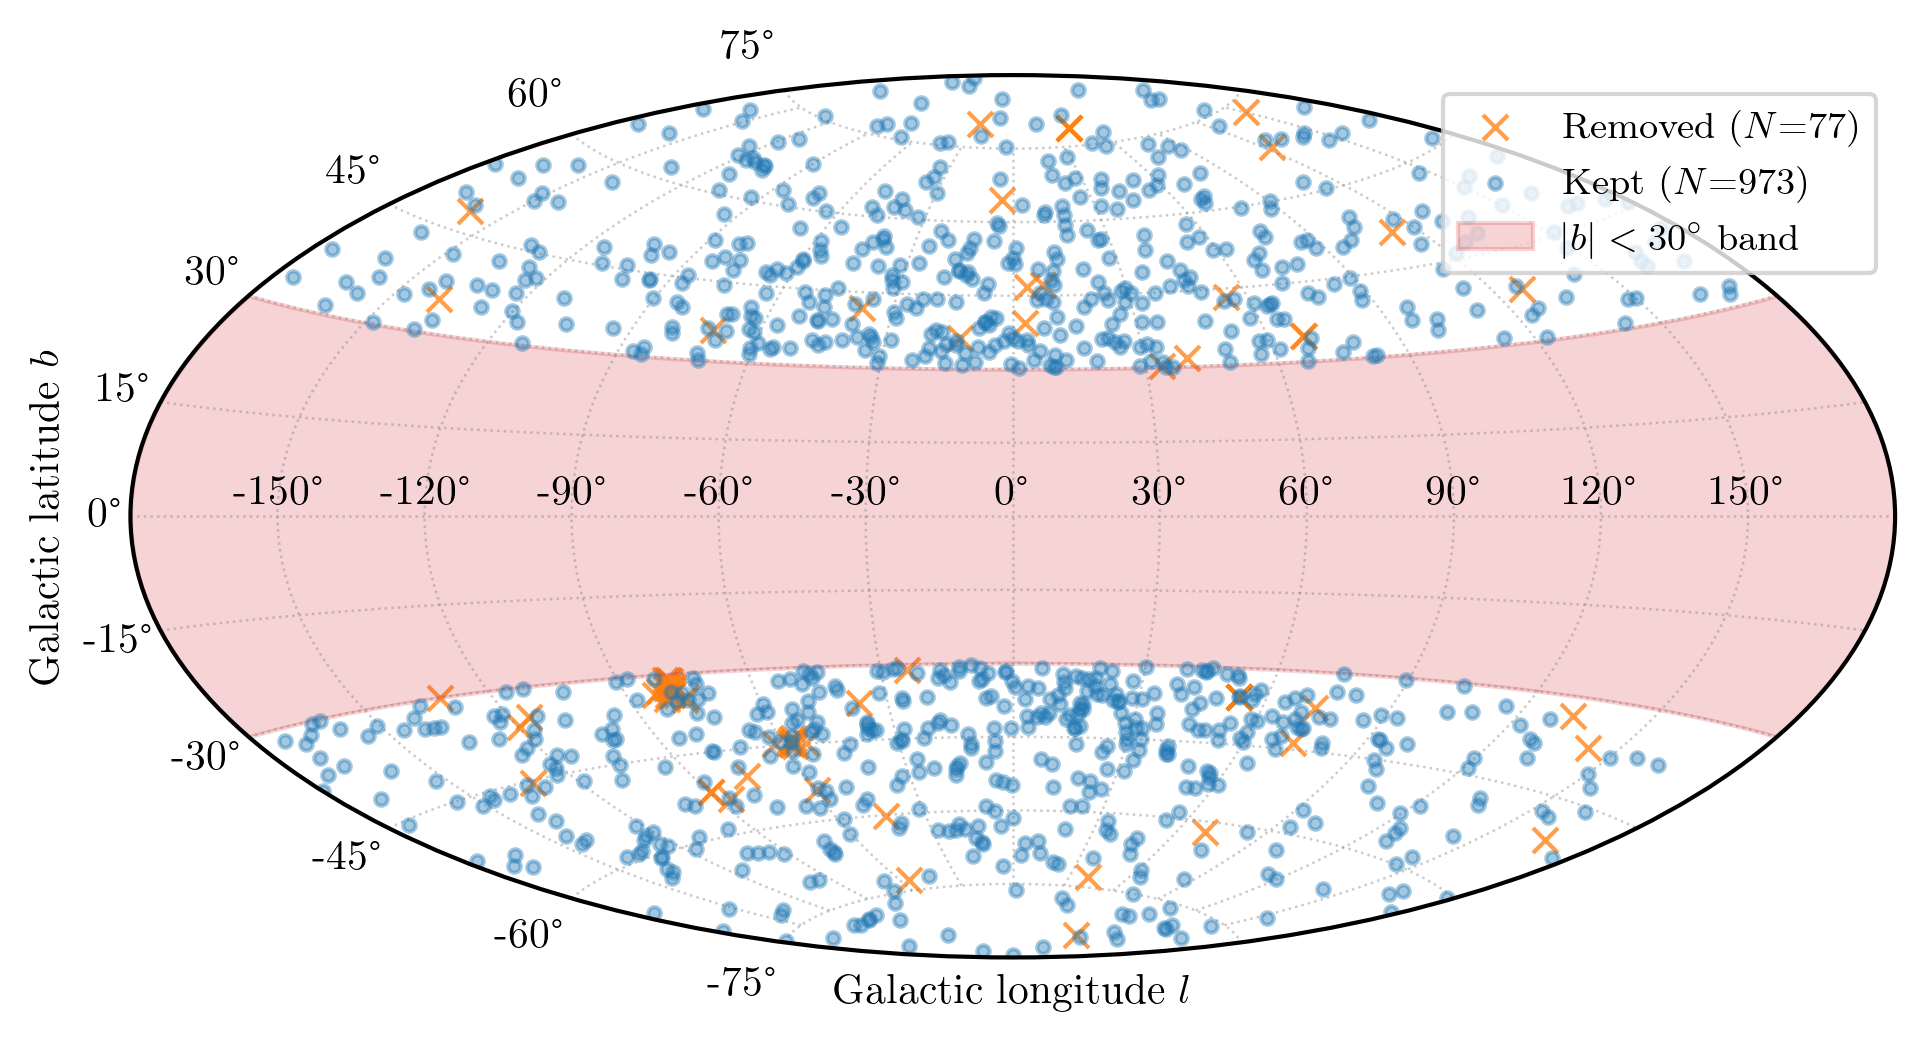

In [3]:
ax = plot_aitoff_diff(rrlyrae_low_dust, c12)
plt.show()

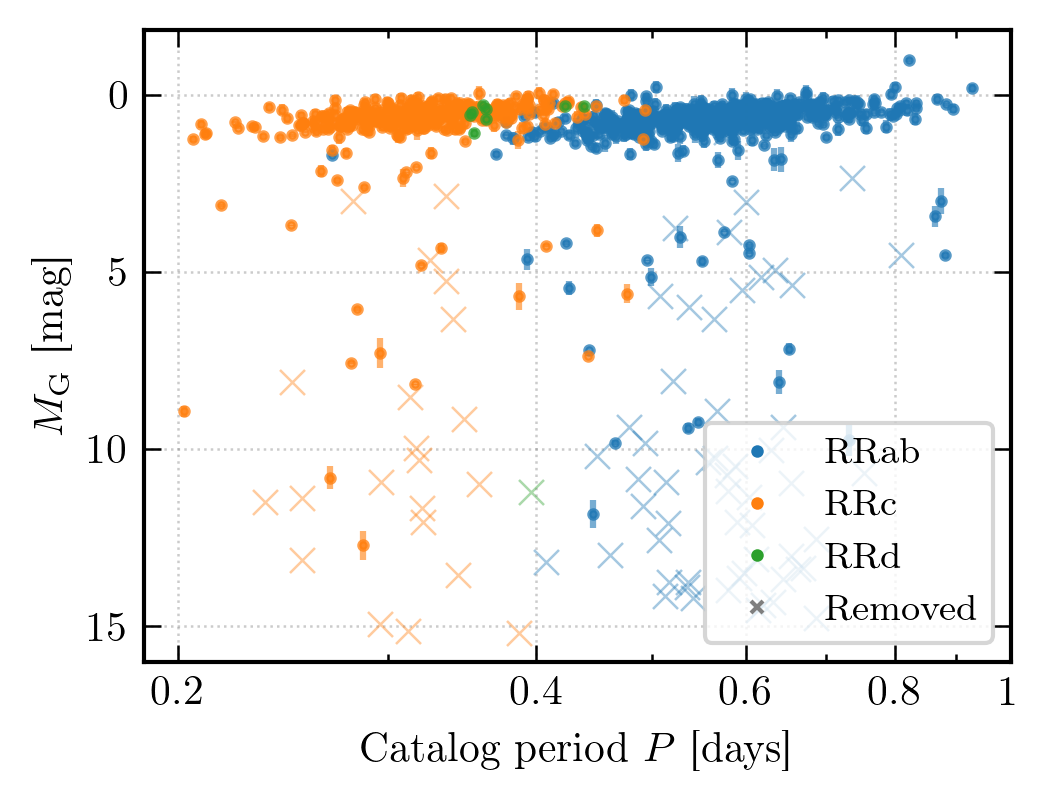

In [4]:
ax = plot_period_abs_mag_c12_comparison(rrlyrae_low_dust, c12)
plt.show()

In [5]:
clean = Deoutlier(c12)
rrlyrae_clean_data = clean.data

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, log10_sig, logit_f]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, log10_sig, logit_f]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, log10_sig, logit_f]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


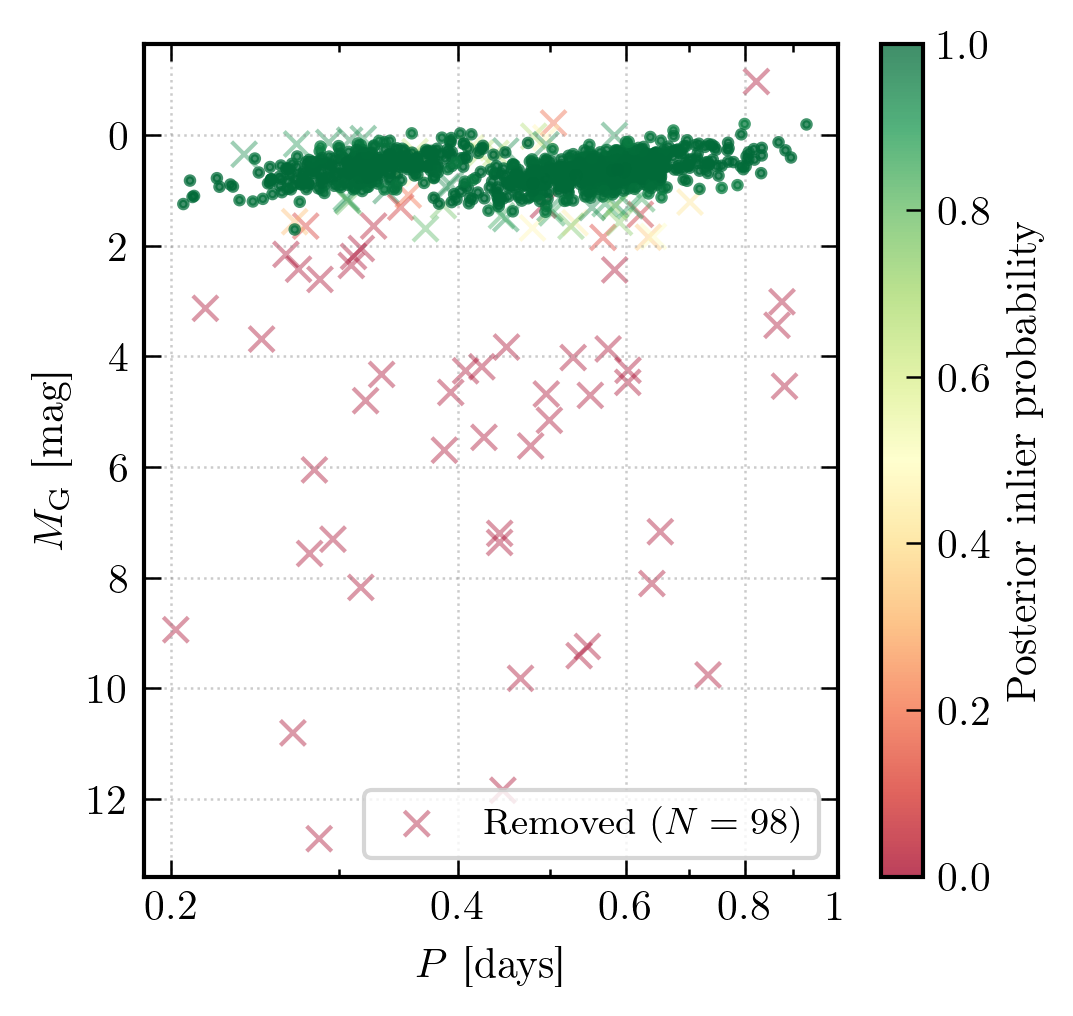

In [6]:
ax = plot_inlier_prob_period_luminosity_comparison(c12, clean)
plt.show()

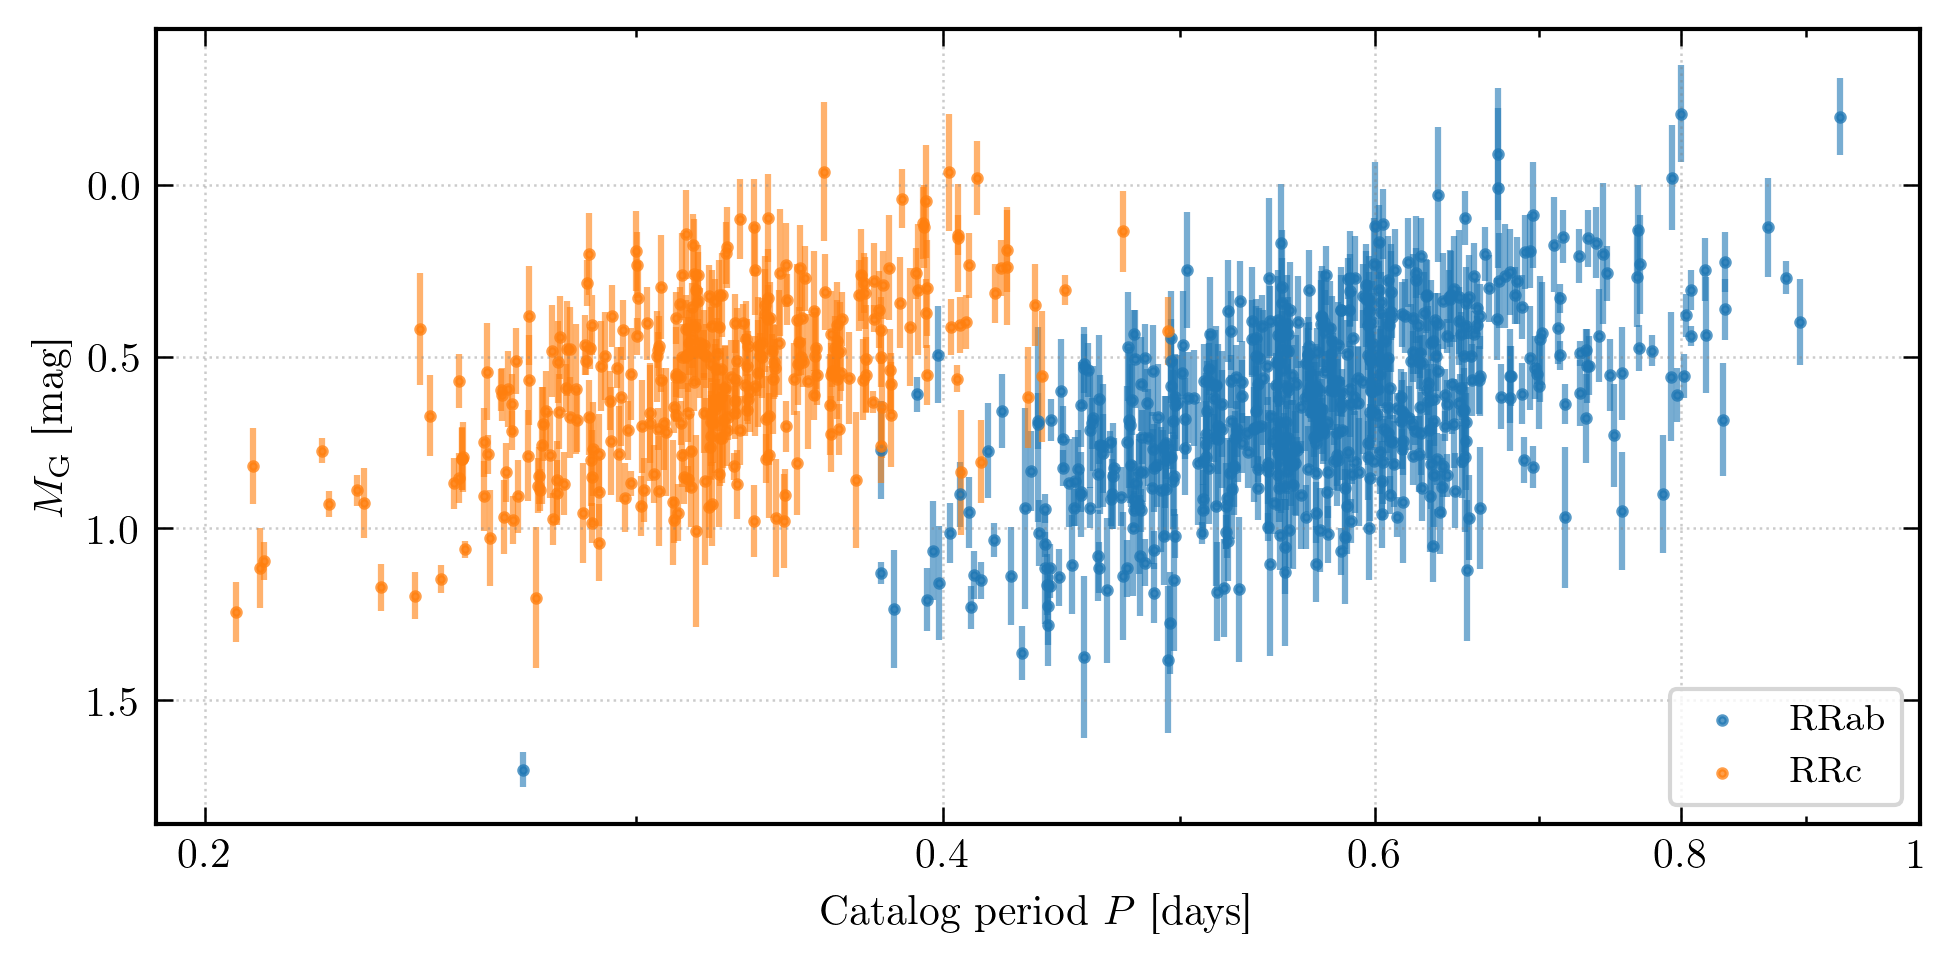

In [7]:
ax = plot_period_abs_mag(rrlyrae_clean_data)
plt.show()

In [8]:
output_path = Path("rrlyrae_calibration_sample.npz")
arrays = {col: np.array(rrlyrae_clean_data[col]) for col in rrlyrae_clean_data.colnames}
np.savez_compressed(output_path, **arrays)